|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Embedding spaces<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge: Math with tokens and embeddings<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# highres plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import GPT-2 model and extract its embeddings matrix

In [2]:
from transformers import GPT2Model,GPT2Tokenizer

# pretrained GPT-2 model and tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# extract embeddings matrix from the gpt2 model
embeddings = gpt2.wte.weight.detach().numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


# Exercise 1: Numbers to tokens

In [14]:
# create some numbers
numbers = np.concatenate([np.arange(11),np.arange(20,100,10),np.arange(100,1001,100)])
numbers = numbers.astype(str)

# initialize token vector
numTokenLabels = np.zeros(len(numbers),dtype=int)

# get and report the tokens
for i,n in enumerate(numbers):

  # get the first token for this number
  numTokenLabels[i] = tokenizer.encode(n)[0]

  # also try diving the number by 2!
  print(f'The number {n} is token(s) {numTokenLabels[i]}')

The number 0 is token(s) 15
The number 1 is token(s) 16
The number 2 is token(s) 17
The number 3 is token(s) 18
The number 4 is token(s) 19
The number 5 is token(s) 20
The number 6 is token(s) 21
The number 7 is token(s) 22
The number 8 is token(s) 23
The number 9 is token(s) 24
The number 10 is token(s) 940
The number 20 is token(s) 1238
The number 30 is token(s) 1270
The number 40 is token(s) 1821
The number 50 is token(s) 1120
The number 60 is token(s) 1899
The number 70 is token(s) 2154
The number 80 is token(s) 1795
The number 90 is token(s) 3829
The number 100 is token(s) 3064
The number 200 is token(s) 2167
The number 300 is token(s) 6200
The number 400 is token(s) 7029
The number 500 is token(s) 4059
The number 600 is token(s) 8054
The number 700 is token(s) 9879
The number 800 is token(s) 7410
The number 900 is token(s) 12865
The number 1000 is token(s) 12825


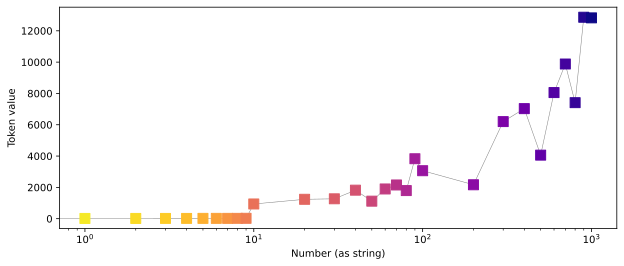

In [24]:
plt.figure(figsize=(10,4))
plt.plot(numbers.astype(int),numTokenLabels,color=[.5,.5,.5],linewidth=.5)
plt.scatter(numbers.astype(int),numTokenLabels,c=np.arange(len(numbers)),s=100,marker='s',cmap='plasma_r',zorder=10)

plt.gca().set(xlabel='Number (as string)',ylabel='Token value',xticks=numbers.astype(int))#,xlim=[numbers[0].astype(int)-15,numbers[-1].astype(int)+15])
plt.gca().set(xscale='log')
plt.show()

# Exercise 2: How long are numbers?

In [ ]:
# tokenize integers and floating-point numbers

# initialize
numnums = 99_999
int_toklens =
float_toklens =

# random numbers
ra = 5*np.random.randn(numnums)

for i in range(numnums):

  # integers


  # and the random numbers


In [ ]:
_,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(,'s',markerfacecolor=[.7,.7,.9],alpha=.4)
axs[1].plot(,'o',markerfacecolor=[.7,.9,.7],alpha=.4)

axs[0].set(xlabel='Number',ylabel='Token length',yticks=range(int_toklens.max()+2),title='Token lengths of integers')
axs[1].set(xlabel='Number',ylabel='Token length',title='Token lengths of floating-point numbers')

plt.tight_layout()
plt.show()

# Exercise 3: Does math work in token conversions?

In [25]:
# the equation and its tokens
eq = '5 x 3 ='
tokens = tokenizer.encode(eq)

# try the math
print(f'{eq} -> {tokens}')
print(f'Product of tokens = {np.prod(tokens)}')
print(f'   which is "{tokenizer.decode(np.prod(tokens))}"')

5 x 3 = -> [20, 2124, 513, 796]
Product of tokens = 17346623040


TypeError: 'NoneType' object is not iterable

In [26]:
# maybe just the numbers?
t5 = tokenizer.encode('5')
t3 = tokenizer.encode('3')

# let's see...
print(f'"5" and "3" have tokens {t5} and {t3}.')
print(f'Their product is {t5[0]*t3[0]}, which is "{tokenizer.decode(t5[0]*t3[0])}"')

"5" and "3" have tokens [20] and [18].
Their product is 360, which is " D"


# Exercise 4: How about embeddings?

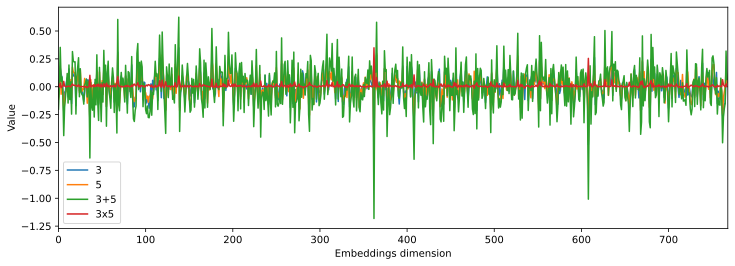

In [27]:
# isolate the embedding vectors
e5 = embeddings[t5,:].squeeze()
e3 = embeddings[t3,:].squeeze()

# math
theirSum = e3 + e5
theirProd = e3 * e5

# plot the vectors
plt.figure(figsize=(12,4))

plt.plot(e3,label='3')
plt.plot(e5,label='5')
plt.plot(theirSum,label='3+5')
plt.plot(theirProd,label='3x5')

plt.gca().set(xlabel='Embeddings dimension',ylabel='Value',xlim=[0,len(e3)])
plt.legend()
plt.show()

In [28]:
# unembedding as transpose of embeddings
sumUnembedding  = theirSum @ embeddings.T 
prodUnembedding = theirProd @ embeddings.T

# print sizes
print(f'Summed vector X embeddings matrix = unembeddings vector')


# find the argmax output
print(f'Max embedding of 5+3 = "{tokenizer.decode(np.argmax(sumUnembedding))}"')
print(f'Max embedding of 5x3 = "{tokenizer.decode(np.argmax(prodUnembedding))}"')

Summed vector X embeddings matrix = unembeddings vector
Max embedding of 5+3 = "5"
Max embedding of 5x3 = " Weinstein"


In [ ]:
# curious to see how the embeddings for '3' and '5' compare
